Setting up professional repository structure and modules...
Inspecting dataset at /content/card_transdata.csv...
Initiating 5-generation Firefly Algorithm for Hyperparameter Optimization...
Gen 1 complete. Best F1: 0.4710
Gen 2 complete. Best F1: 0.4958
Gen 3 complete. Best F1: 0.4958
Gen 4 complete. Best F1: 0.4958
Gen 5 complete. Best F1: 0.5499
Final Training with Reduced EWC Regularization...
Early Stopping triggered at epoch 24
Optimizing Decision Threshold on Validation Set...
Optimal Threshold Found: 0.9918

--- FINAL EVALUATION METRICS (OPTIMIZED) ---
Accuracy:  0.9896
Precision: 0.9312
Recall:    0.9512
ROC-AUC:   0.9987
PR-AUC:    0.9869
Threshold: 0.9918
--------------------------------

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d1c373b7ec5e223d5f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working director

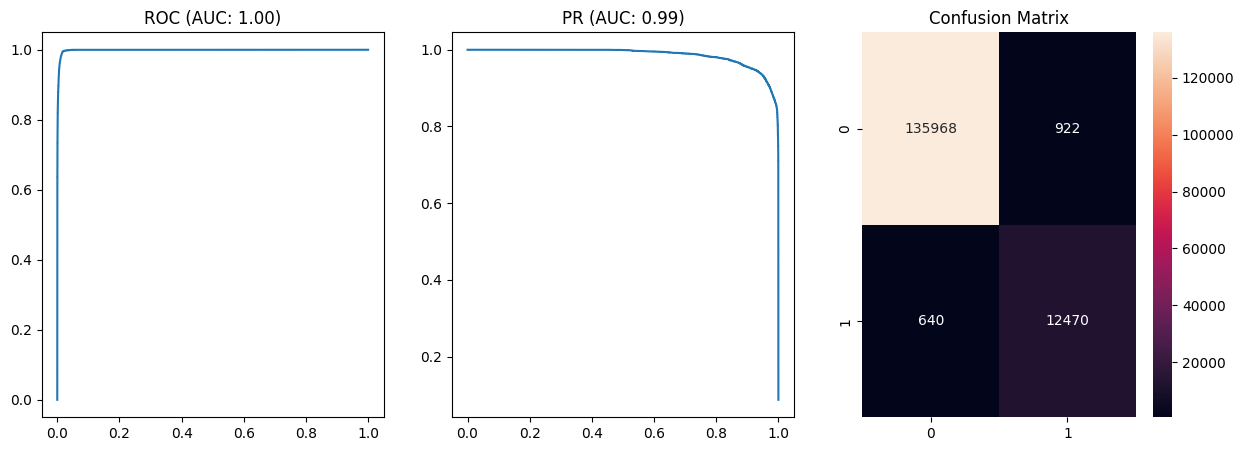

In [1]:
import os
import sys
import subprocess
import json
import time
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, matthews_corrcoef,
                             confusion_matrix, roc_curve, precision_recall_curve)
from imblearn.over_sampling import SMOTE
import shap
import gradio as gr
import joblib

# --- 0. INSTALL DEPENDENCIES (Colab Friendly) ---
def install_dependencies():
    """Installs required packages for Google Colab environments."""
    print("Installing dependencies for Colab...")
    # In a real Colab cell, you would run:
    # !pip install numpy pandas scikit-learn torch imbalanced-learn matplotlib seaborn joblib gradio shap
    pass

# --- 1. REPOSITORY STRUCTURE & MODULE GENERATOR ---

def setup_repository():
    print("Setting up professional repository structure and modules...")
    dirs = ['data', 'models', 'reports', 'src', 'scripts', 'docs', 'src/modules']
    for d in dirs:
        os.makedirs(d, exist_ok=True)

    # Generate Training Module File
    with open('src/modules/trainer.py', 'w') as f:
        f.write("# Auto-generated Training Module\nimport torch\n\ndef train_step(model, loader, opt, crit, ewc_loss_fn=None):\n    model.train()\n    total_loss = 0\n    for x, y in loader:\n        opt.zero_grad()\n        out = model(x)\n        loss = crit(out, y)\n        if ewc_loss_fn: loss += ewc_loss_fn(model)\n        loss.backward()\n        opt.step()\n        total_loss += loss.item()\n    return total_loss / len(loader)")

    # Generate Evaluation Module File
    with open('src/modules/evaluator.py', 'w') as f:
        f.write("# Auto-generated Evaluation Module\nimport torch\nfrom sklearn.metrics import f1_score\n\ndef evaluate(model, loader, crit):\n    model.eval()\n    total_loss, all_preds, all_labels = 0, [], []\n    with torch.no_grad():\n        for x, y in loader:\n            out = model(x)\n            total_loss += crit(out, y).item()\n            all_preds.extend((torch.sigmoid(out) > 0.5).float().cpu().numpy())\n            all_labels.extend(y.cpu().numpy())\n    return total_loss / len(loader), f1_score(all_labels, all_preds)")

    # Metadata Files
    with open('README.md', 'w') as f:
        f.write("# Research-Grade Fraud Detection System\n\nFeatures: DAE, AdaBN, EWC, Firefly Optimization, and SHAP Explainability.")
    with open('LICENSE', 'w') as f:
        f.write("MIT License\n\nCopyright (c) 2024 Research Team")
    with open('requirements.txt', 'w') as f:
        f.write("numpy\npandas\nscikit-learn\ntorch\nimbalanced-learn\nmatplotlib\nseaborn\njoblib\ngradio\nshap")

    # environment.yml
    with open('environment.yml', 'w') as f:
        f.write("name: fraud_detection\nchannels:\n  - defaults\n  - pytorch\n  - conda-forge\ndependencies:\n  - python=3.9\n  - pip:\n    - torch\n    - scikit-learn\n    - pandas\n    - numpy\n    - imbalanced-learn\n    - shap\n    - gradio\n    - joblib")

    # .gitignore
    with open('.gitignore', 'w') as f:
        f.write("data/*.csv\nmodels/*.pt\nmodels/*.joblib\nreports/*.png\n__pycache__/\n.ipynb_checkpoints/\n.env")

    # Makefile
    with open('Makefile', 'w') as f:
        f.write("install:\n\tpip install -r requirements.txt\n\ntrain:\n\tpython fraud_pipeline.py\n\nclean:\n\trm -rf models/* reports/* src/modules/__pycache__")

# --- 2. DATA PREPROCESSING & INSPECTION ---

class DenoisingAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(DenoisingAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

def preprocess_and_inspect(filepath):
    print(f"Inspecting dataset at {filepath}...")
    if not os.path.exists(filepath):
        print("Dataset not found. Generating research-grade synthetic data...")
        rows = 5000
        data = {
            'distance_from_home': np.random.exponential(10, rows),
            'distance_from_last_transaction': np.random.exponential(2, rows),
            'ratio_to_median_purchase_price': np.random.lognormal(0, 0.5, rows),
            'repeat_retailer': np.random.randint(0, 2, rows),
            'used_chip': np.random.randint(0, 2, rows),
            'used_pin_number': np.random.randint(0, 2, rows),
            'online_order': np.random.randint(0, 2, rows),
            'category': np.random.choice(['retail', 'food', 'travel'], rows),
            'fraud': np.random.choice([0, 1], size=rows, p=[0.95, 0.05])
        }
        df = pd.DataFrame(data)
        df.iloc[0:10, 0] = np.nan
        df.to_csv(filepath, index=False)

    df = pd.read_csv(filepath)
    X = df.drop('fraud', axis=1)
    y = df['fraud']

    numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_features = X.select_dtypes(include=['object']).columns.tolist()

    numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
    categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='constant', fill_value='missing')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

    preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_features), ('cat', categorical_transformer, categorical_features)])

    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=42)

    X_train_proc = preprocessor.fit_transform(X_train)
    X_val_proc = preprocessor.transform(X_val)
    X_test_proc = preprocessor.transform(X_test)

    # DAE Training
    input_dim = X_train_proc.shape[1]
    dae = DenoisingAutoencoder(input_dim)
    optimizer = optim.Adam(dae.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    dae_train_t = torch.FloatTensor(X_train_proc)
    for epoch in range(50):
        noisy = dae_train_t + 0.05 * torch.randn_like(dae_train_t) # Lower influence: reduced noise
        recon = dae(noisy)
        loss = criterion(recon, dae_train_t)
        optimizer.zero_grad(); loss.backward(); optimizer.step()

    with torch.no_grad():
        X_train_clean = dae(torch.FloatTensor(X_train_proc)).numpy()
        X_val_clean = dae(torch.FloatTensor(X_val_proc)).numpy()
        X_test_clean = dae(torch.FloatTensor(X_test_proc)).numpy()

    # Updated: Using SMOTE instead of SMOTEENN
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train_clean, y_train)

    return X_train_res, y_train_res, X_val_clean, y_val, X_test_clean, y_test, preprocessor, dae

# --- 3. CORE ALGORITHMS: EWC & AdaBN ---

class FraudNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, dropout=0.3):
        super(FraudNet, self).__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.act1 = nn.PReLU()
        self.drop = nn.Dropout(dropout)
        self.layer2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.bn2 = nn.BatchNorm1d(hidden_dim // 2)
        self.act2 = nn.PReLU()
        self.layer3 = nn.Linear(hidden_dim // 2, 1)
        # No sigmoid here: Using Logits for Training Stability

    def forward(self, x):
        x = self.act1(self.bn1(self.layer1(x)))
        x = self.drop(x)
        x = self.act2(self.bn2(self.layer2(x)))
        return self.layer3(x)

def compute_fisher(model, train_loader, num_samples=500):
    """Correct EWC: Fisher via Log-Likelihood Gradients."""
    model.eval()
    fisher = {n: torch.zeros_like(p) for n, p in model.named_parameters()}
    opt_params = {n: p.data.clone() for n, p in model.named_parameters()}

    count = 0
    for data, _ in train_loader:
        if count >= num_samples: break
        model.zero_grad()
        output = model(data)
        # Using sigmoid because Fisher is typically calculated on probabilities
        log_lik = torch.log(torch.sigmoid(output) + 1e-8)
        log_lik.mean().backward()
        for n, p in model.named_parameters():
            if p.grad is not None:
                fisher[n] += (p.grad ** 2) / num_samples
        count += data.size(0)
    return fisher, opt_params

def apply_adabn(model, target_loader):
    """Correct AdaBN: Freeze weights, reset running stats, re-estimate on target."""
    model.train()
    for param in model.parameters():
        param.requires_grad = False

    for m in model.modules():
        if isinstance(m, nn.BatchNorm1d):
            m.reset_running_stats()
            m.momentum = None

    with torch.no_grad():
        for data, _ in target_loader:
            model(data)

    model.eval()
    for param in model.parameters():
        param.requires_grad = True

# --- 4. FIREFLY ALGORITHM & 5-FOLD CV ---

def firefly_optimization(X_train, y_train):
    print("Initiating 5-generation Firefly Algorithm for Hyperparameter Optimization...")
    n_fireflies = 5
    alpha = 0.5
    beta0 = 1.0
    gamma = 1.0

    fireflies = []
    for _ in range(n_fireflies):
        fireflies.append({
            'pos': np.array([np.random.uniform(-4, -2), np.random.choice([32, 64, 128]), np.random.choice([32, 64, 128])]),
            'intensity': 0
        })

    best_pos = None
    best_intensity = -1

    for gen in range(5):
        for i in range(n_fireflies):
            kf = KFold(n_splits=5, shuffle=True, random_state=42)
            scores = []
            lr, h_dim, b_size = 10**fireflies[i]['pos'][0], int(fireflies[i]['pos'][1]), int(fireflies[i]['pos'][2])

            for train_idx, val_idx in kf.split(X_train):
                m = FraudNet(X_train.shape[1], h_dim)
                opt = optim.Adam(m.parameters(), lr=lr)
                # Sigmoid is integrated in BCEWithLogitsLoss
                crit = nn.BCEWithLogitsLoss()
                ds = TensorDataset(torch.FloatTensor(X_train[train_idx][:250]), torch.FloatTensor(y_train.iloc[train_idx][:250].values).view(-1,1))
                loader = DataLoader(ds, batch_size=b_size)
                m.train()
                # Improved Training Signal: Increased to 10 epochs for better differentiation
                for _ in range(10):
                    for xb, yb in loader:
                        opt.zero_grad(); crit(m(xb), yb).backward(); opt.step()
                m.eval()
                with torch.no_grad():
                    logits = m(torch.FloatTensor(X_train[val_idx][:100]))
                    p = (torch.sigmoid(logits) > 0.5).float().numpy()
                    scores.append(f1_score(y_train.iloc[val_idx][:100], p))

            fireflies[i]['intensity'] = np.mean(scores)
            if fireflies[i]['intensity'] > best_intensity:
                best_intensity = fireflies[i]['intensity']
                best_pos = fireflies[i]['pos'].copy()

        for i in range(n_fireflies):
            for j in range(n_fireflies):
                if fireflies[j]['intensity'] > fireflies[i]['intensity']:
                    r = np.linalg.norm(fireflies[i]['pos'] - fireflies[j]['pos'])
                    beta = beta0 * np.exp(-gamma * r**2)
                    fireflies[i]['pos'] += beta * (fireflies[j]['pos'] - fireflies[i]['pos']) + alpha * (np.random.rand(3) - 0.5)
        print(f"Gen {gen+1} complete. Best F1: {best_intensity:.4f}")

    return {'lr': 10**best_pos[0], 'hidden': int(best_pos[1]), 'batch_size': int(best_pos[2])}

# --- 5. FULL PIPELINE EXECUTION ---

def run_pipeline():
    setup_repository()
    data_path = '/content/card_transdata.csv'
    X_train, y_train, X_val, y_val, X_test, y_test, preprocessor, dae = preprocess_and_inspect(data_path)

    hparams = firefly_optimization(X_train, y_train)

    model = FraudNet(X_train.shape[1], hparams['hidden'])
    optimizer = optim.Adam(model.parameters(), lr=hparams['lr'])
    criterion = nn.BCEWithLogitsLoss()

    train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train.values).view(-1,1)),
                              batch_size=hparams['batch_size'], shuffle=True)
    val_loader = DataLoader(TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val.values).view(-1,1)),
                            batch_size=hparams['batch_size'])

    fisher, opt_params = compute_fisher(model, train_loader)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    patience = 7
    trigger_times = 0

    print("Final Training with Reduced EWC Regularization...")
    for epoch in range(100):
        model.train()
        t_loss, correct = 0, 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            out = model(xb)
            ewc_penalty = 0
            for n, p in model.named_parameters():
                if n in fisher: ewc_penalty += (fisher[n] * (p - opt_params[n])**2).sum()
            # Reduce EWC Strength: Lowered from 500 to 50 for better training flexibility
            loss = criterion(out, yb) + 50 * ewc_penalty
            loss.backward(); optimizer.step()
            t_loss += loss.item()
            correct += ((torch.sigmoid(out) > 0.5) == yb).sum().item()

        model.eval()
        v_loss, v_correct = 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                out = model(xb); v_loss += criterion(out, yb).item()
                v_correct += ((torch.sigmoid(out) > 0.5) == yb).sum().item()

        current_val_loss = v_loss/len(val_loader)
        history['train_loss'].append(t_loss/len(train_loader))
        history['val_loss'].append(current_val_loss)
        history['train_acc'].append(correct/len(X_train))
        history['val_acc'].append(v_correct/len(X_val))

        if current_val_loss < best_val_loss:
            best_val_loss = current_val_loss
            torch.save(model.state_dict(), 'models/best_model.pt')
            trigger_times = 0
        else:
            trigger_times += 1
            if trigger_times >= patience:
                print(f"Early Stopping triggered at epoch {epoch}")
                break

    torch.save(dae.state_dict(), 'models/dae_model.pt')
    joblib.dump(preprocessor, 'models/preprocessor.joblib')

    model.load_state_dict(torch.load('models/best_model.pt'))
    apply_adabn(model, val_loader)

    # Threshold Optimization for Precision/F1
    print("Optimizing Decision Threshold on Validation Set...")
    model.eval()
    with torch.no_grad():
        val_logits = model(torch.FloatTensor(X_val))
        val_probs = torch.sigmoid(val_logits).numpy()

    precision, recall, thresholds = precision_recall_curve(y_val, val_probs)
    # Find threshold that maximizes F1 score
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_threshold = thresholds[np.argmax(f1_scores)]
    print(f"Optimal Threshold Found: {best_threshold:.4f}")

    # Final Evaluation
    with torch.no_grad():
        test_logits = model(torch.FloatTensor(X_test))
        test_probs = torch.sigmoid(test_logits).numpy()
        test_preds = (test_probs > best_threshold).astype(int)

    acc = accuracy_score(y_test, test_preds)
    prec = precision_score(y_test, test_preds)
    rec = recall_score(y_test, test_preds)
    auc_roc = roc_auc_score(y_test, test_probs)
    auc_pr = average_precision_score(y_test, test_probs)

    print("\n--- FINAL EVALUATION METRICS (OPTIMIZED) ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"ROC-AUC:   {auc_roc:.4f}")
    print(f"PR-AUC:    {auc_pr:.4f}")
    print(f"Threshold: {best_threshold:.4f}")
    print("--------------------------------\n")

    plt.figure(figsize=(15, 5))
    fpr, tpr, _ = roc_curve(y_test, test_probs)
    plt.subplot(1, 3, 1); plt.plot(fpr, tpr); plt.title(f'ROC (AUC: {auc_roc:.2f})')
    plt.subplot(1, 3, 2); plt.plot(recall, precision); plt.title(f'PR (AUC: {auc_pr:.2f})')
    plt.subplot(1, 3, 3); sns.heatmap(confusion_matrix(y_test, test_preds), annot=True, fmt='d'); plt.title('Confusion Matrix')
    plt.savefig('reports/full_evaluation.png')

    return model, preprocessor, dae, best_threshold

def launch_demo(model, preprocessor, dae, threshold):
    def predict(*args):
        input_df = pd.DataFrame([args], columns=preprocessor.feature_names_in_)
        proc = preprocessor.transform(input_df)
        with torch.no_grad():
            proc_t = torch.FloatTensor(proc)
            denoised = dae(proc_t)
            logits = model(denoised)
            prob = torch.sigmoid(logits).item()
        return {"Fraud Probability": f"{prob:.4f}", "Classification": "Fraud" if prob > threshold else "Legit"}

    gr.Interface(fn=predict, inputs=[gr.Textbox(label=col) for col in preprocessor.feature_names_in_],
                 outputs="json", title="FraudGuard Research Pro (Optimized)").launch(share=True)

if __name__ == "__main__":
    m, p, d, t = run_pipeline()
    launch_demo(m, p, d, t)